In [1]:
suppressPackageStartupMessages(library(SingleCellExperiment))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(argparse))
suppressPackageStartupMessages(library(Seurat))

#####################
## Define settings ##
#####################
here::i_am("processing/1_create_seurat_rna.R")
source(here::here("settings.R"))
source(here::here("utils.R"))



here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/code



In [54]:
args = list()
#args$stages <- 'E7.5'
args$sample <- opts$samples[8]
args$sce <- io$rna.sce
args$metadata <- "/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/mapping/sample_metadata_after_mapping.txt.gz"
# args$metadata <- paste0(io$basedir,"/results/rna/doublets/sample_metadata_after_doublets.txt.gz")
args$features <- 3000
args$npcs <- 40
args$n_neighbors = 30
args$min_dist = 0.3
args$test <- FALSE
args$colour_by <- c("celltype.mapped_mnn","sample")
args$vars.to.regress <- c("nFeature_RNA","mitochondrial_percent_RNA")
args$batch_correction <- c("stage")
args$remove_ExE_cells <- FALSE
args$outdir <- paste0(io$basedir,"/results/rna/mapping/test")

In [55]:
dir.create(args$outdir, recursive=TRUE, showWarnings = FALSE)

### Prepare query data

In [56]:
sample_metadata <- fread(args$metadata) %>%
   .[pass_rnaQC==TRUE & doublet_call==FALSE & sample %in% args$sample]

if (args$remove_ExE_cells) {
  print("Removing ExE cells...")
  sample_metadata <- sample_metadata %>%
    .[!celltype.mapped_mnn%in%c("Visceral_endoderm","ExE_endoderm","ExE_ectoderm","Parietal_endoderm")]
}

In [57]:
nrow(sample_metadata)

[1] 2117

In [58]:
###################
## Sanity checks ##
###################

stopifnot(args$colour_by %in% colnames(sample_metadata))
# stopifnot(unique(sample_metadata$celltype.mapped) %in% names(opts$celltype.colors))

 if (length(args$batch_correction)>0) {
   stopifnot(args$batch_correction%in%colnames(sample_metadata))
   if (length(unique(sample_metadata[[args$batch_correction]]))==1) {
     message(sprintf("There is a single level for %s, no batch correction applied",args$batch_correction))
     args$batch_correction <- NULL
   } else {
     library(batchelor)
   }
 }

 if (length(args$vars_to_regress)>0) {
  stopifnot(args$vars_to_regress%in%colnames(sample_metadata))
 }

There is a single level for stage, no batch correction applied



In [59]:

###############
## Load data ##
###############

# Load RNA expression data as SingleCellExperiment object
sce <- load_SingleCellExperiment(args$sce, cells=sample_metadata$cell, normalise = TRUE)

# Add sample metadata as colData
colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame


In [60]:
seurat = as.Seurat(sce)

### Prepare atlas data

In [15]:
atlas.integrated = readRDS(paste0(args$outdir, '/atlas_integrated.rds'))

### Transfer labels

In [18]:
# Multi core using future - built in to seurat
plan("multicore", workers = 24)
options(future.globals.maxSize = 150 * 1024 ^ 3) # for 50 Gb RAM

In [19]:
# seurat.anchors <- FindTransferAnchors(reference = atlas.integrated, query = seurat,
#     dims = 1:30, reference.reduction = "pca")


Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 1578 anchors

Filtering anchors

	Retained 1251 anchors



ERROR: Error in TransferData(anchorset = seurat.anchors, refdata = atlas.integrated$celltype_extended_atlas, : unused arguments (k.anchor = 20, max.features = 2000)


In [61]:
#For real ones use k.anchors etc here!!! 
seurat.anchors <- FindTransferAnchors(reference = atlas.integrated, query = seurat,
                            k.anchor = 20,
                            max.features = 2000,
    dims = 1:30, reference.reduction = "pca")


Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 18633 anchors

Filtering anchors

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.3 GiB”
	Retained 14733 anchors



In [62]:

predictions <- TransferData(anchorset = seurat.anchors, 
                            refdata = atlas.integrated$celltype_extended_atlas,
                            dims = 1:30)

Finding integration vectors

Finding integration vector weights

Predicting cell labels



In [63]:
seurat <- AddMetaData(seurat, metadata = predictions)

In [64]:
new_umap = fread('/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/dimensionality_reduction/sce/umap_features3000_pcs40_neigh30_dist0.3.txt.gz')

In [65]:
test = merge(as.data.table(seurat@meta.data, keep.rownames=T) %>% setnames('rn', 'cell'),
             new_umap, 
             by = 'cell',
            all.y=T) 

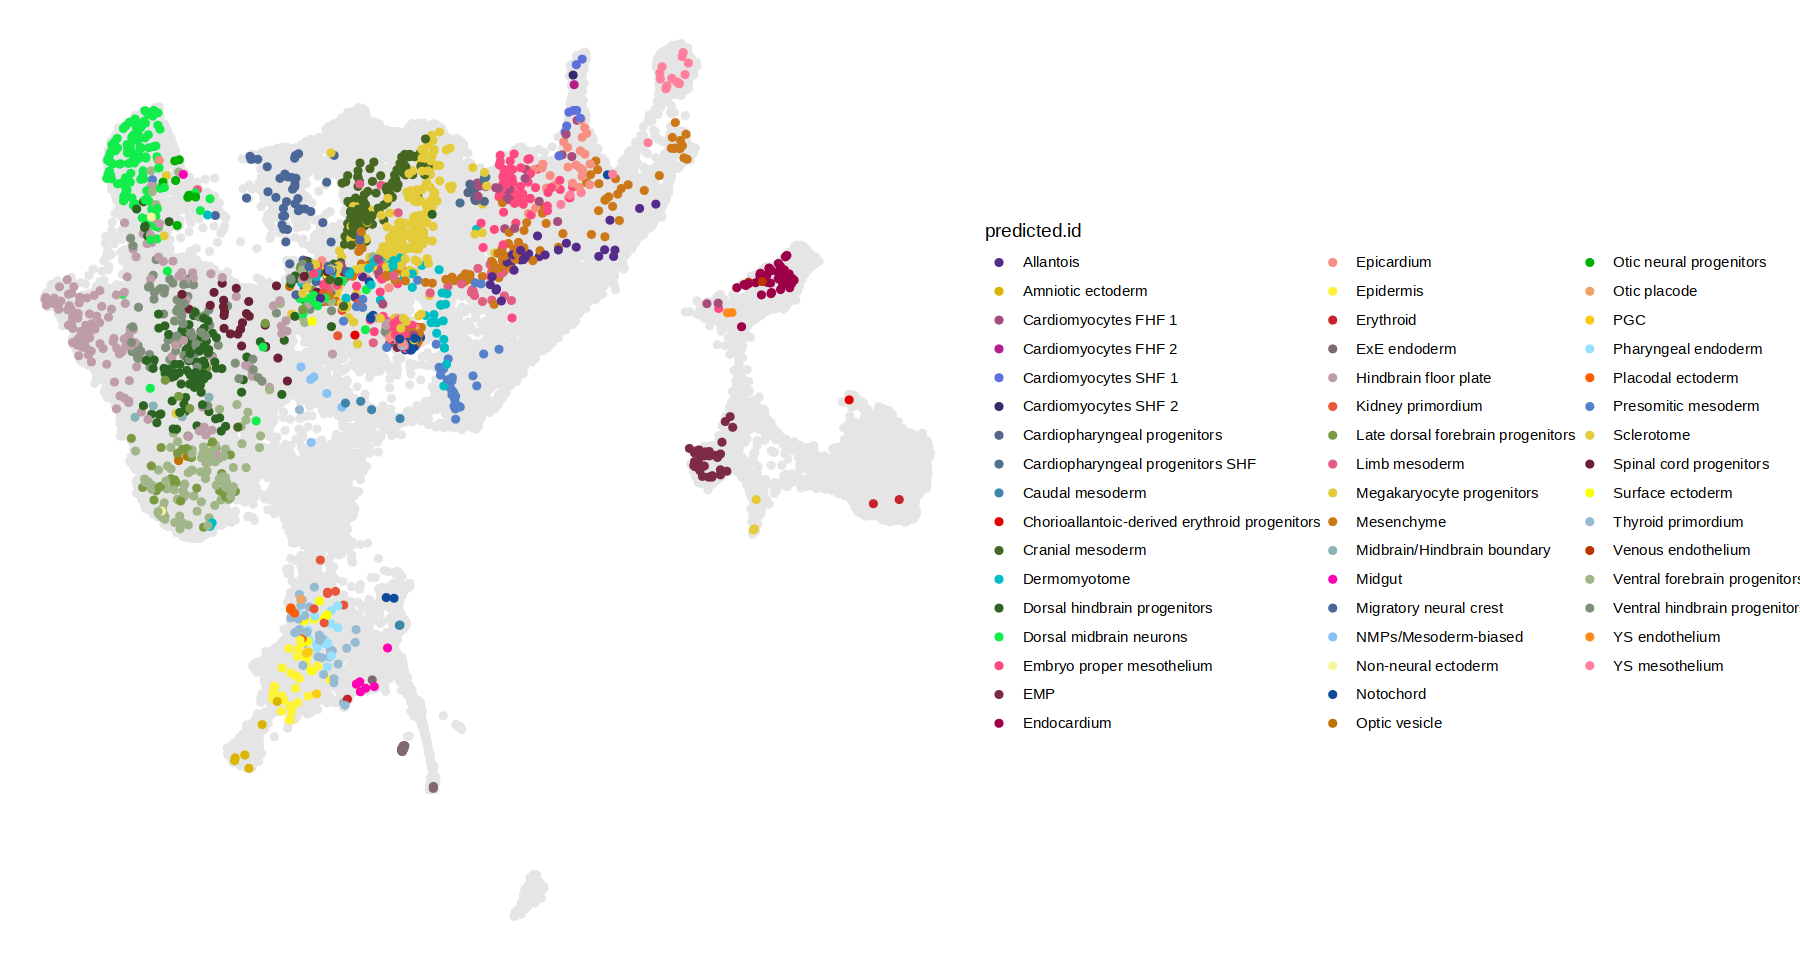

In [66]:
options(repr.plot.width=15, repr.plot.height=8)

ggplot(test[!is.na(predicted.id)], aes(UMAP1, UMAP2, col=predicted.id)) + 
    geom_point(data = test[is.na(predicted.id)], color='grey90') + 
    geom_point() + 
    scale_color_manual(values=opts$celltype.colors) + 
    theme_void()

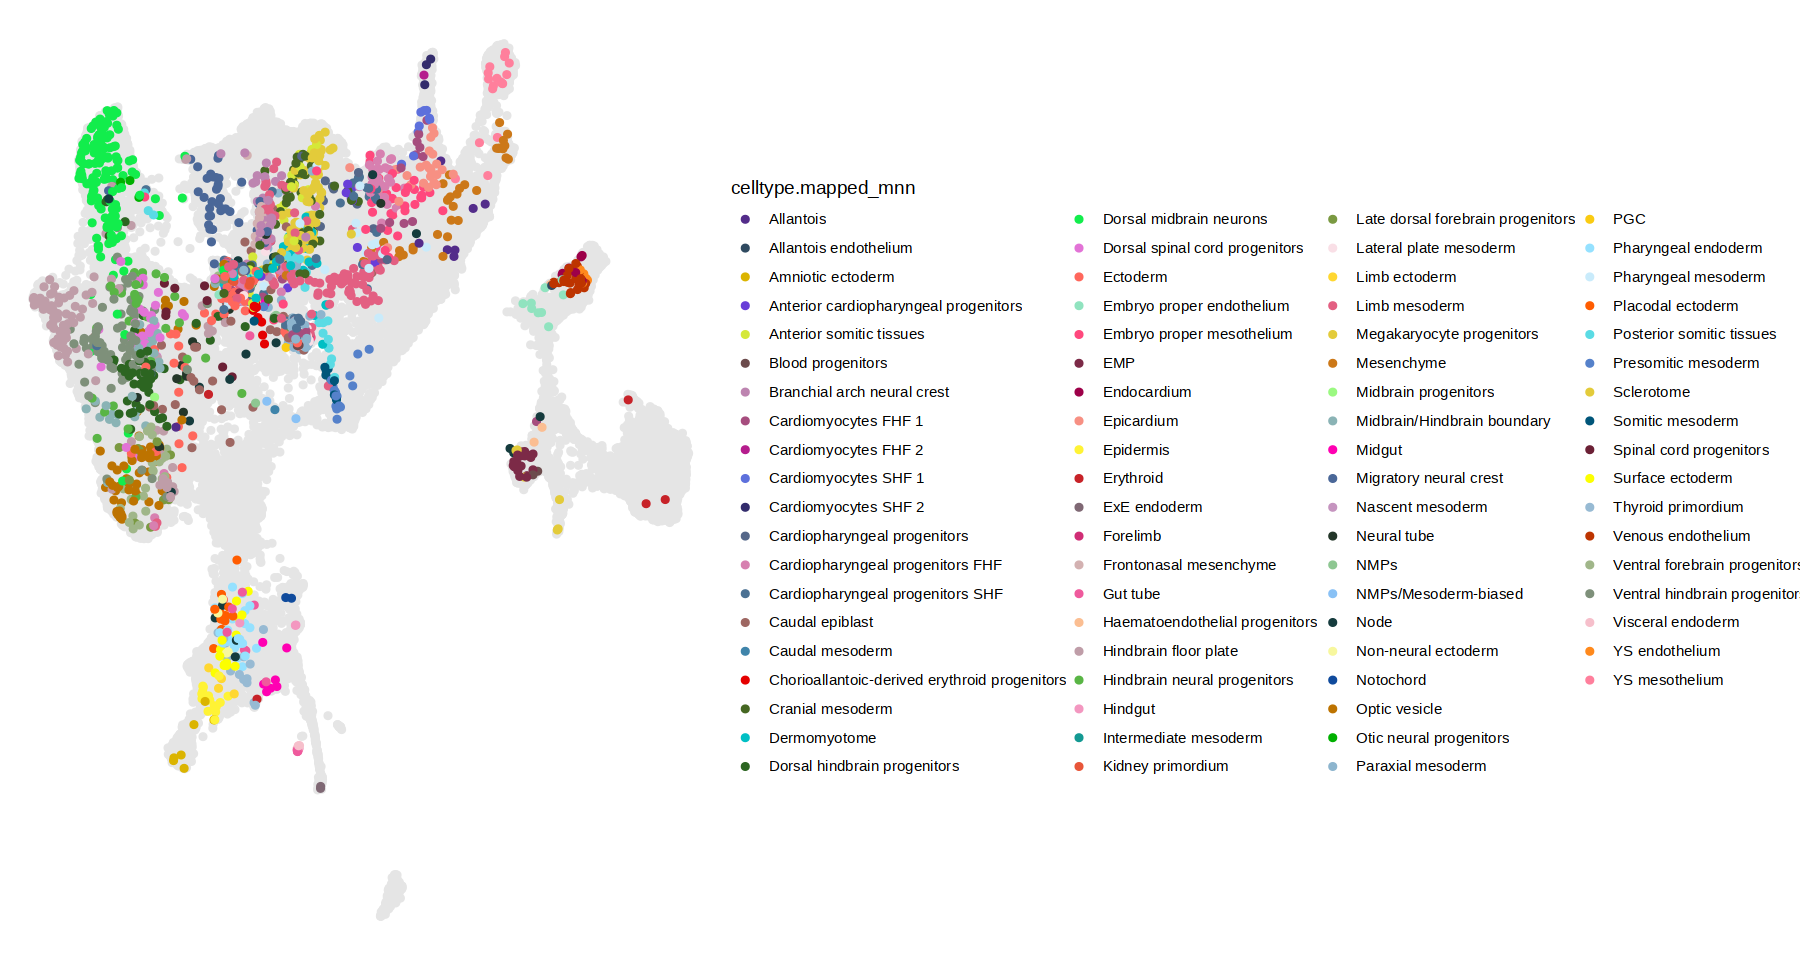

In [67]:
ggplot(test[!is.na(predicted.id)], aes(UMAP1, UMAP2, col=celltype.mapped_mnn)) + 
    geom_point(data = test[is.na(predicted.id)], color='grey90') + 
    geom_point() + 
    scale_color_manual(values=opts$celltype.colors) + 
    theme_void()

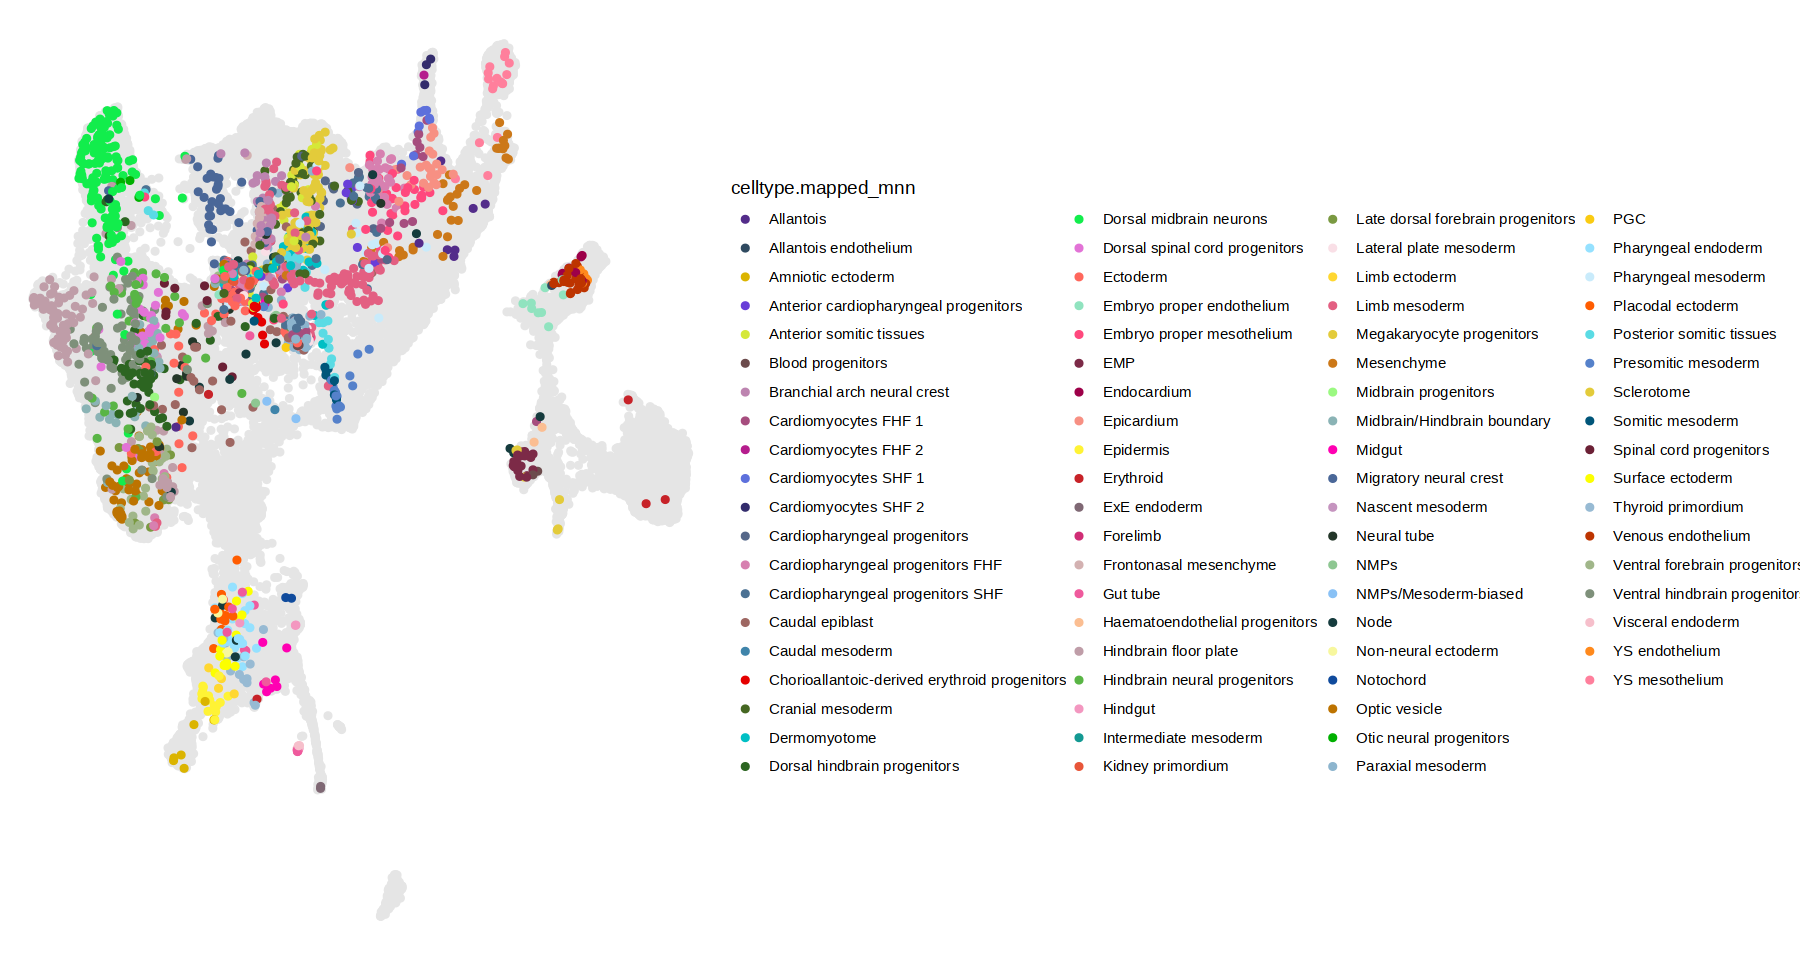

In [68]:
ggplot(test[!is.na(predicted.id)], aes(UMAP1, UMAP2, col=celltype.mapped_mnn)) + 
    geom_point(data = test[is.na(predicted.id)], color='grey90') + 
    geom_point() + 
    scale_color_manual(values=opts$celltype.colors) + 
    theme_void()

In [69]:
seurat

An object of class Seurat 
29453 features across 2117 samples within 1 assay 
Active assay: RNA (29453 features, 0 variable features)

### transfer with reciprocal PCA

In [71]:
#For real ones use k.anchors etc here!!! 
seurat.anchors <- FindTransferAnchors(reference = atlas.integrated, query = seurat,
                            k.anchor = 20,
                            max.features = 2000,
    dims = 1:30, reduction = "rpca")


Performing PCA on the provided reference using 1995 features as input.

Centering and scaling data matrix

Performing PCA on the provided query using 1995 features as input.

Centering and scaling data matrix

Projecting new data onto SVD

Projecting new data onto SVD

Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 29314 anchors

Filtering anchors

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.3 GiB”
	Retained 26384 anchors



In [72]:

predictions <- TransferData(anchorset = seurat.anchors, 
                            refdata = atlas.integrated$celltype_extended_atlas,
                            dims = 1:30)

Finding integration vectors

Finding integration vector weights

Predicting cell labels



In [73]:
seurat <- AddMetaData(seurat, metadata = predictions)

In [74]:
new_umap = fread('/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/dimensionality_reduction/sce/umap_features3000_pcs40_neigh30_dist0.3.txt.gz')

In [75]:
test = merge(as.data.table(seurat@meta.data, keep.rownames=T) %>% setnames('rn', 'cell'),
             new_umap, 
             by = 'cell',
            all.y=T) 

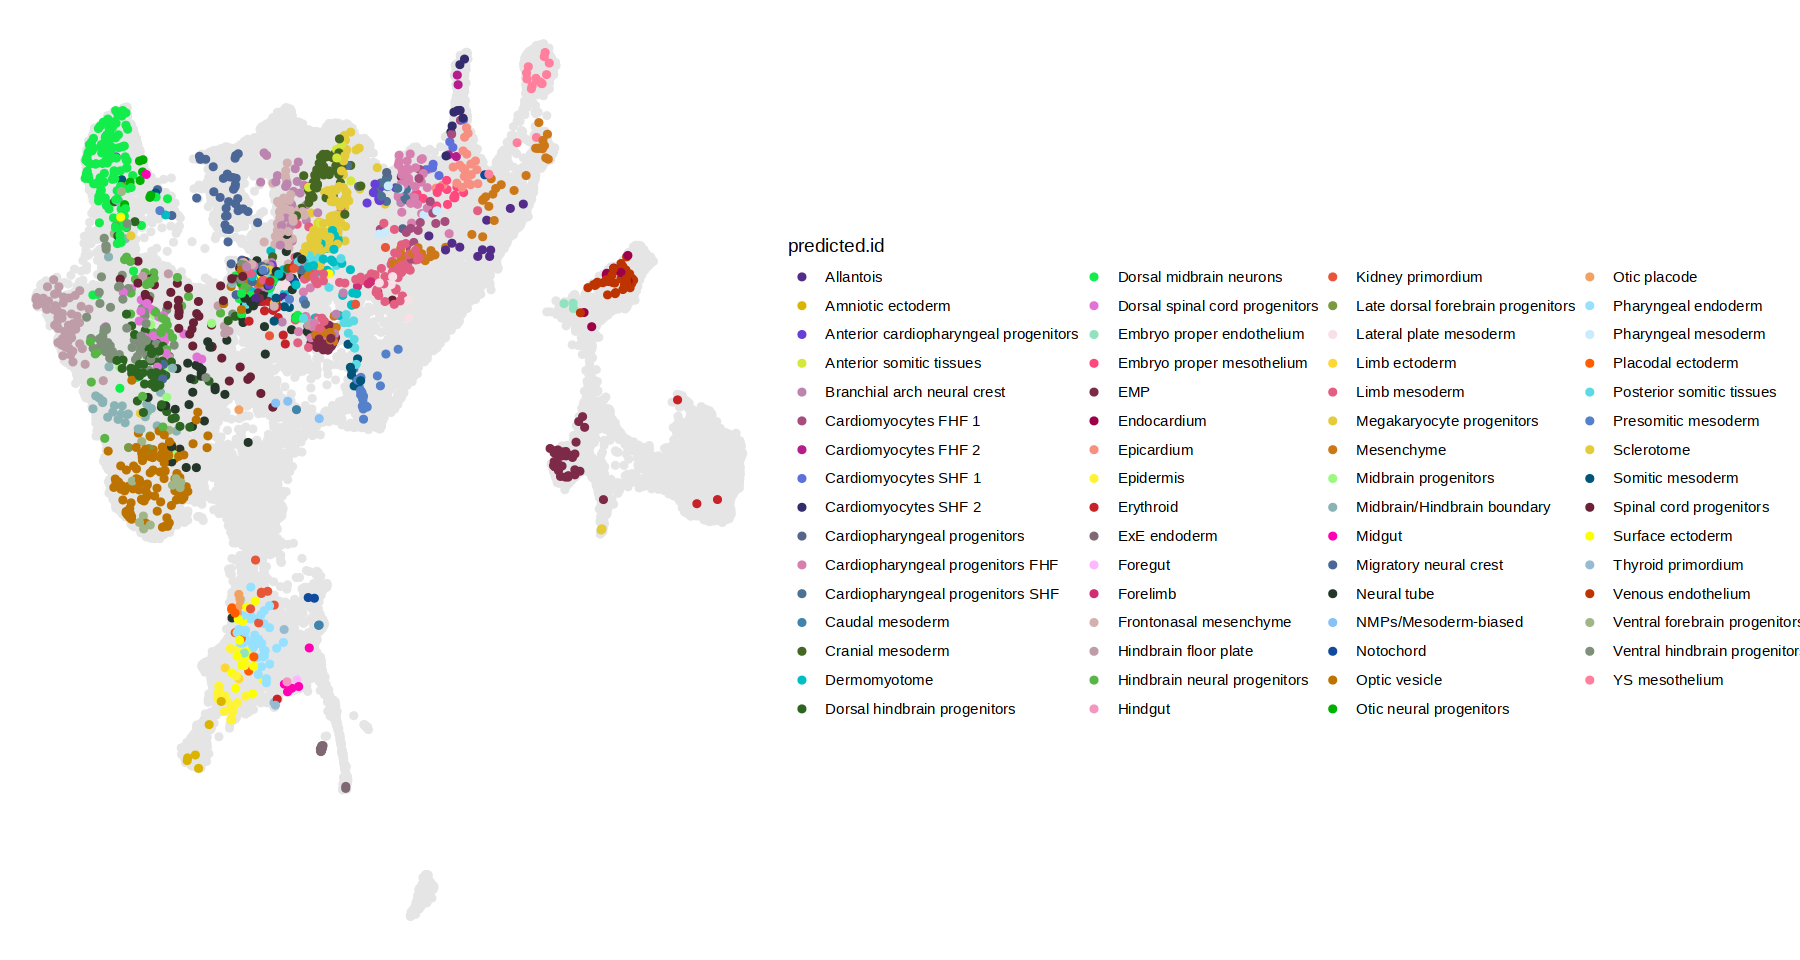

In [76]:
options(repr.plot.width=15, repr.plot.height=8)

ggplot(test[!is.na(predicted.id)], aes(UMAP1, UMAP2, col=predicted.id)) + 
    geom_point(data = test[is.na(predicted.id)], color='grey90') + 
    geom_point() + 
    scale_color_manual(values=opts$celltype.colors) + 
    theme_void()

In [80]:
opts$sample2pool[order(opts$sample2pool)]

SLX-21143_SITTD5_HTJH3DSX2 SLX-21143_SITTE5_HTJH3DSX2 
               "E7.5_rep1"                "E7.5_rep1" 
SLX-21143_SITTF5_HTJH3DSX2 SLX-21143_SITTG5_HTJH3DSX2 
               "E7.5_rep2"                "E7.5_rep2" 
SLX-21143_SITTA2_HTJH3DSX2 SLX-21143_SITTB2_HTJH3DSX2 
               "E8.5_rep1"                "E8.5_rep1" 
SLX-21143_SITTG1_HTJH3DSX2 SLX-21143_SITTH1_HTJH3DSX2 
               "E8.5_rep2"                "E8.5_rep2" 
SLX-21143_SITTE3_HTJH3DSX2 SLX-21143_SITTF3_HTJH3DSX2 
               "E9.5_rep1"                "E9.5_rep1" 
SLX-21143_SITTG3_HTJH3DSX2 SLX-21143_SITTH3_HTJH3DSX2 
               "E9.5_rep2"                "E9.5_rep2" 
SLX-21143_SITTA4_HTJH3DSX2 SLX-21143_SITTB4_HTJH3DSX2 
               "E9.5_rep3"                "E9.5_rep3" 
SLX-21143_SITTC4_HTJH3DSX2 SLX-21143_SITTD4_HTJH3DSX2 
               "E9.5_rep4"                "E9.5_rep4"